# IT Fusion — MARIA Training (Image + Text Cross-Modal Fusion)
Trains FusionClassifier using EfficientFormerV2 image features (288-d) and Bio_ClinicalBERT text features (768-d)
with MARIA-style cross-modal attention. Classes grouped to Top-50 + Other for learnability.

In [16]:
import os, sys, json
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR, LambdaLR
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
from tqdm import tqdm
from pathlib import Path

FUSION_DIR = Path('/home/vjti-comp/Desktop/Final Project Code/it_fusion_modular_project')
sys.path.insert(0, str(FUSION_DIR))

from maria_fusion import FusionClassifier

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Device:', DEVICE)

Device: cuda


## Config

In [17]:
DATASET_PATH = Path('/data/Stagewise Dataset/IT Fusion/prepared/it_fusion_maria_dataset.parquet')
CHECKPOINT_DIR = FUSION_DIR / 'checkpoints'
CHECKPOINT_DIR.mkdir(exist_ok=True)

# ── Class grouping ──
TOP_K_CLASSES = 50   # keep top-50 most frequent classes, rest → 'Other'

# ── Feature dimensions (from dataset) ──
IMAGE_DIM = 288   # EfficientFormerV2-S2
TEXT_DIM  = 768   # Bio_ClinicalBERT

# ── Training hyperparameters ──
BATCH_SIZE   = 64
EPOCHS       = 50     # increased from 30 — model was still improving
LR           = 3e-4
WEIGHT_DECAY = 1e-4
D_MODEL      = 256
N_HEADS      = 8
N_LAYERS     = 3
DROPOUT      = 0.2
LABEL_SMOOTH = 0.1
WARMUP_EPOCHS= 3
PATIENCE     = 10    # early stopping patience
TRAIN_SPLIT  = 0.70
VAL_SPLIT    = 0.15
SEED = 42

torch.manual_seed(SEED)
np.random.seed(SEED)
print('Config set')

Config set


## Dataset (Image + Text Features with Class Grouping)

In [18]:
class ITFusionDataset(Dataset):
    """Reads pre-extracted image & text features with top-K class grouping."""

    def __init__(self, parquet_path, top_k=50):
        df = pd.read_parquet(parquet_path)
        df = df[df['target_class'] >= 0].reset_index(drop=True)
        print(f'Loaded {len(df)} labeled samples, {df["target_class"].nunique()} original classes')
        print(df['dataset'].value_counts().to_string())

        # ── Group to top-K classes ──
        vc = df['target_class'].value_counts()
        top_classes = set(vc.head(top_k).index.tolist())
        print(f'\nKeeping top-{top_k} classes ({sum(vc.head(top_k))} samples)')
        print(f'Remaining {len(vc) - top_k} classes → "Other"')

        # Build remapping: original_class → new_class (0..top_k)
        sorted_top = sorted(top_classes)
        self.class_remap = {orig: new_idx for new_idx, orig in enumerate(sorted_top)}
        self.other_idx = top_k  # last index = 'Other'

        df['grouped_class'] = df['target_class'].apply(
            lambda c: self.class_remap.get(c, self.other_idx)
        )

        # Build label names
        label2name = df.drop_duplicates('target_class').set_index('target_class')['disease_label'].to_dict()
        self.class_names = [label2name.get(c, str(c)) for c in sorted_top] + ['Other']
        self.n_classes = top_k + 1

        self.df = df
        print(f'Final class count: {self.n_classes}')
        print(f'\nGrouped class distribution (top 10):')
        gvc = df['grouped_class'].value_counts().head(10)
        for idx in gvc.index:
            print(f'  [{idx:2d}] {self.class_names[idx][:50]:50s} → {gvc[idx]:>6d}')

    def __len__(self): return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_feat = torch.tensor(row['image_features'], dtype=torch.float32)
        txt_feat = torch.tensor(row['text_features'],  dtype=torch.float32)
        label    = torch.tensor(int(row['grouped_class']), dtype=torch.long)

        # Masks: 1.0 if features are non-zero (present), 0.0 if missing
        img_mask = torch.tensor(1.0 if img_feat.abs().sum() > 1e-6 else 0.0)
        txt_mask = torch.tensor(1.0 if txt_feat.abs().sum() > 1e-6 else 0.0)

        return img_feat, txt_feat, img_mask, txt_mask, label


full_ds = ITFusionDataset(DATASET_PATH, top_k=TOP_K_CLASSES)
N = len(full_ds)
n_train = int(N * TRAIN_SPLIT)
n_val   = int(N * VAL_SPLIT)
n_test  = N - n_train - n_val
train_ds, val_ds, test_ds = random_split(
    full_ds, [n_train, n_val, n_test],
    generator=torch.Generator().manual_seed(SEED)
)
print(f'\nSplit: train={n_train}  val={n_val}  test={n_test}')

Loaded 415508 labeled samples, 22708 original classes
dataset
DERM1M         413210
PAD-UFES-20      2298

Keeping top-50 classes (280027 samples)
Remaining 22658 classes → "Other"
Final class count: 51

Grouped class distribution (top 10):
  [50] Other                                              → 135481
  [34] no definitive diagnosis                            → 102380
  [ 2] allergic contact dermatitis                        →  47510
  [22] irritated seborrheic keratosis (from "sk/isk")     →  15906
  [37] psoriasis                                          →  13794
  [33] nevus                                              →   8706
  [30] melanoma                                           →   8025
  [15] eczema                                             →   6808
  [24] keratosis                                          →   4688
  [ 6] basal cell carcinoma                               →   4683

Split: train=290855  val=62326  test=62327


In [19]:
def collate_fn(batch):
    img_feats = torch.stack([b[0] for b in batch])
    txt_feats = torch.stack([b[1] for b in batch])
    img_masks = torch.stack([b[2] for b in batch])
    txt_masks = torch.stack([b[3] for b in batch])
    labels    = torch.stack([b[4] for b in batch])
    return img_feats, txt_feats, img_masks, txt_masks, labels

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=4, collate_fn=collate_fn, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=4, collate_fn=collate_fn, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=4, collate_fn=collate_fn, pin_memory=True)
print(f'Batches: train={len(train_loader)}  val={len(val_loader)}  test={len(test_loader)}')

Batches: train=4545  val=974  test=974


## Model + Optimizer

In [20]:
n_classes = full_ds.n_classes
print(f'Classes: {n_classes} (top-{TOP_K_CLASSES} + Other)')

model = FusionClassifier(
    image_dim=IMAGE_DIM, text_dim=TEXT_DIM,
    d_model=D_MODEL, n_classes=n_classes,
    n_heads=N_HEADS, n_layers=N_LAYERS,
    dropout=DROPOUT
).to(DEVICE)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Trainable params: {n_params:,}')

# Class-weighted loss with label smoothing
label_counts = full_ds.df['grouped_class'].value_counts().sort_index().values
class_weights = torch.tensor(1.0 / np.sqrt(label_counts + 1), dtype=torch.float32).to(DEVICE)
class_weights = class_weights / class_weights.sum() * n_classes
criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=LABEL_SMOOTH)

optimizer = AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

# Cosine schedule with linear warmup
def lr_lambda(epoch):
    if epoch < WARMUP_EPOCHS:
        return (epoch + 1) / WARMUP_EPOCHS
    progress = (epoch - WARMUP_EPOCHS) / max(1, EPOCHS - WARMUP_EPOCHS)
    return 0.5 * (1 + np.cos(np.pi * progress))

scheduler = LambdaLR(optimizer, lr_lambda)
print('Model, loss, optimizer ready')

Classes: 51 (top-50 + Other)
Trainable params: 2,558,261
Model, loss, optimizer ready


## Training Loop

In [21]:
def train_epoch(model, loader):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for img_f, txt_f, img_m, txt_m, labels in loader:
        img_f  = img_f.to(DEVICE)
        txt_f  = txt_f.to(DEVICE)
        img_m  = img_m.to(DEVICE)
        txt_m  = txt_m.to(DEVICE)
        labels = labels.to(DEVICE)

        optimizer.zero_grad()
        logits, _, _ = model(img_f, txt_f, img_m, txt_m)
        loss = criterion(logits, labels)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        total_loss += loss.item()
        correct    += (logits.argmax(1) == labels).sum().item()
        total      += len(labels)
    return total_loss / len(loader), correct / total

@torch.no_grad()
def eval_epoch(model, loader):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels, all_gates = [], [], []
    for img_f, txt_f, img_m, txt_m, labels in loader:
        img_f  = img_f.to(DEVICE)
        txt_f  = txt_f.to(DEVICE)
        img_m  = img_m.to(DEVICE)
        txt_m  = txt_m.to(DEVICE)
        labels = labels.to(DEVICE)

        logits, _, gate_w = model(img_f, txt_f, img_m, txt_m)
        loss = criterion(logits, labels)

        total_loss += loss.item()
        preds = logits.argmax(1)
        correct += (preds == labels).sum().item()
        total   += len(labels)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_gates.extend(gate_w.cpu().numpy())
    return total_loss / len(loader), correct / total, all_preds, all_labels, all_gates

print('Training functions defined')

Training functions defined


In [22]:
history = {'train_loss':[], 'train_acc':[], 'val_loss':[], 'val_acc':[]}
best_val_acc = 0.0
epochs_no_improve = 0
BEST_CKPT = str(CHECKPOINT_DIR / 'maria_fusion_best.pt')

for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc = train_epoch(model, train_loader)
    vl_loss, vl_acc, _, _, _ = eval_epoch(model, val_loader)
    scheduler.step()

    history['train_loss'].append(tr_loss)
    history['train_acc'].append(tr_acc)
    history['val_loss'].append(vl_loss)
    history['val_acc'].append(vl_acc)

    lr_now = optimizer.param_groups[0]['lr']
    print(f'Ep {epoch:3d}/{EPOCHS}  '
          f'tr_loss={tr_loss:.4f} tr_acc={tr_acc:.3f}  '
          f'vl_loss={vl_loss:.4f} vl_acc={vl_acc:.3f}  '
          f'lr={lr_now:.2e}')

    if vl_acc > best_val_acc:
        best_val_acc = vl_acc
        epochs_no_improve = 0
        torch.save(model.state_dict(), BEST_CKPT+'1')
        print(f'  ✓ Saved best checkpoint (val_acc={vl_acc:.4f})')
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= PATIENCE:
            print(f'  ⚠ Early stopping at epoch {epoch} (no improvement for {PATIENCE} epochs)')
            break

print(f'\nBest Val Acc: {best_val_acc:.4f}')
print(f'Total epochs trained: {len(history["train_loss"])}')

Ep   1/50  tr_loss=3.8717 tr_acc=0.526  vl_loss=3.4810 vl_acc=0.601  lr=2.00e-04
  ✓ Saved best checkpoint (val_acc=0.6014)
Ep   2/50  tr_loss=3.5445 tr_acc=0.583  vl_loss=3.3758 vl_acc=0.620  lr=3.00e-04
  ✓ Saved best checkpoint (val_acc=0.6201)
Ep   3/50  tr_loss=3.4617 tr_acc=0.593  vl_loss=3.3299 vl_acc=0.612  lr=3.00e-04
Ep   4/50  tr_loss=3.3739 tr_acc=0.605  vl_loss=3.2782 vl_acc=0.604  lr=3.00e-04
Ep   5/50  tr_loss=3.3124 tr_acc=0.611  vl_loss=3.2014 vl_acc=0.628  lr=2.99e-04
  ✓ Saved best checkpoint (val_acc=0.6282)
Ep   6/50  tr_loss=3.2637 tr_acc=0.611  vl_loss=3.2098 vl_acc=0.614  lr=2.97e-04
Ep   7/50  tr_loss=3.2248 tr_acc=0.612  vl_loss=3.2090 vl_acc=0.640  lr=2.95e-04
  ✓ Saved best checkpoint (val_acc=0.6402)
Ep   8/50  tr_loss=3.1915 tr_acc=0.614  vl_loss=3.2353 vl_acc=0.597  lr=2.92e-04
Ep   9/50  tr_loss=3.1652 tr_acc=0.616  vl_loss=3.0685 vl_acc=0.626  lr=2.88e-04
Ep  10/50  tr_loss=3.1351 tr_acc=0.619  vl_loss=3.0777 vl_acc=0.601  lr=2.84e-04
Ep  11/50  tr_loss

## Results & Evaluation

In [23]:
# Load best checkpoint and evaluate on test set
model.load_state_dict(torch.load(BEST_CKPT, map_location=DEVICE))
ts_loss, ts_acc, preds, labels, gates = eval_epoch(model, test_loader)
print(f'Test Loss: {ts_loss:.4f}  Test Acc: {ts_acc:.4f}')

# Build target_names only for classes that appear in test set
present_classes = sorted(set(labels) | set(preds))
present_names   = [full_ds.class_names[c] if c < len(full_ds.class_names) else str(c)
                   for c in present_classes]

print('\nClassification Report:')
print(classification_report(labels, preds, labels=present_classes,
                           target_names=present_names, zero_division=0))

Test Loss: 2.7962  Test Acc: 0.6629

Classification Report:
                                                                          precision    recall  f1-score   support

                                                                    acne       0.37      0.48      0.41       358
actinic solar damage(actinic keratosis), basal cell carcinoma, keratosis       1.00      1.00      1.00       199
                                             allergic contact dermatitis       0.98      0.95      0.97      7166
             allergic contact dermatitis, contact dermatitis, dermatitis       0.73      0.78      0.75       144
                                                                alopecia       0.19      0.41      0.26       169
                                           atopic dermatitis, dermatitis       0.38      0.45      0.41       297
                                                    basal cell carcinoma       0.57      0.73      0.64       681
                           

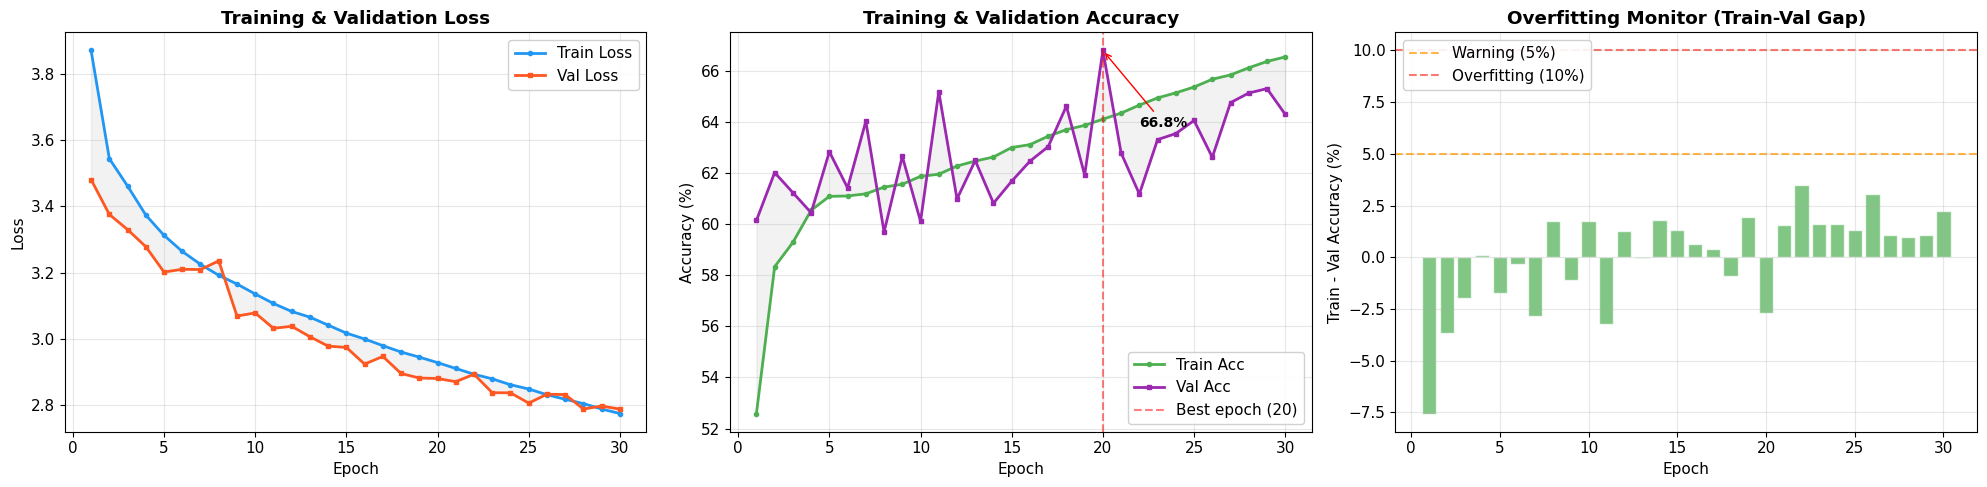

Training curves saved


In [24]:
# ═══════════════════════════════════════════════════════════════
# Professional Training Curves
# ═══════════════════════════════════════════════════════════════
import matplotlib
matplotlib.rcParams.update({
    'font.family': 'sans-serif', 'font.size': 11,
    'axes.grid': True, 'grid.alpha': 0.3,
    'figure.facecolor': 'white'
})

epochs_range = range(1, len(history['train_loss']) + 1)

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# ── Panel 1: Loss curves ──
ax = axes[0]
ax.plot(epochs_range, history['train_loss'], 'o-', ms=3, lw=2, label='Train Loss', color='#2196F3')
ax.plot(epochs_range, history['val_loss'],   's-', ms=3, lw=2, label='Val Loss',   color='#FF5722')
ax.fill_between(epochs_range, history['train_loss'], history['val_loss'], alpha=0.1, color='gray')
ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
ax.set_title('Training & Validation Loss', fontweight='bold')
ax.legend(loc='upper right', framealpha=0.9)

# ── Panel 2: Accuracy curves ──
ax = axes[1]
ax.plot(epochs_range, [a*100 for a in history['train_acc']], 'o-', ms=3, lw=2, label='Train Acc', color='#4CAF50')
ax.plot(epochs_range, [a*100 for a in history['val_acc']],   's-', ms=3, lw=2, label='Val Acc',   color='#9C27B0')
ax.fill_between(epochs_range,
                [a*100 for a in history['train_acc']],
                [a*100 for a in history['val_acc']], alpha=0.1, color='gray')
best_ep = np.argmax(history['val_acc']) + 1
best_va = max(history['val_acc']) * 100
ax.axvline(best_ep, ls='--', color='red', alpha=0.5, label=f'Best epoch ({best_ep})')
ax.annotate(f'{best_va:.1f}%', xy=(best_ep, best_va), fontsize=10, fontweight='bold',
            xytext=(best_ep+2, best_va-3), arrowprops=dict(arrowstyle='->', color='red'))
ax.set_xlabel('Epoch'); ax.set_ylabel('Accuracy (%)')
ax.set_title('Training & Validation Accuracy', fontweight='bold')
ax.legend(loc='lower right', framealpha=0.9)

# ── Panel 3: Train-Val Gap (overfit monitor) ──
ax = axes[2]
gap = [((t - v) * 100) for t, v in zip(history['train_acc'], history['val_acc'])]
colors = ['#4CAF50' if g < 5 else '#FF9800' if g < 10 else '#F44336' for g in gap]
ax.bar(epochs_range, gap, color=colors, alpha=0.7, edgecolor='white')
ax.axhline(5, ls='--', color='#FF9800', alpha=0.7, label='Warning (5%)')
ax.axhline(10, ls='--', color='#F44336', alpha=0.7, label='Overfitting (10%)')
ax.set_xlabel('Epoch'); ax.set_ylabel('Train - Val Accuracy (%)')
ax.set_title('Overfitting Monitor (Train-Val Gap)', fontweight='bold')
ax.legend(loc='upper left', framealpha=0.9)

plt.tight_layout()
plt.savefig(str(CHECKPOINT_DIR / 'training_curves.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Training curves saved')

## Confusion Matrix (Top-15 Classes)

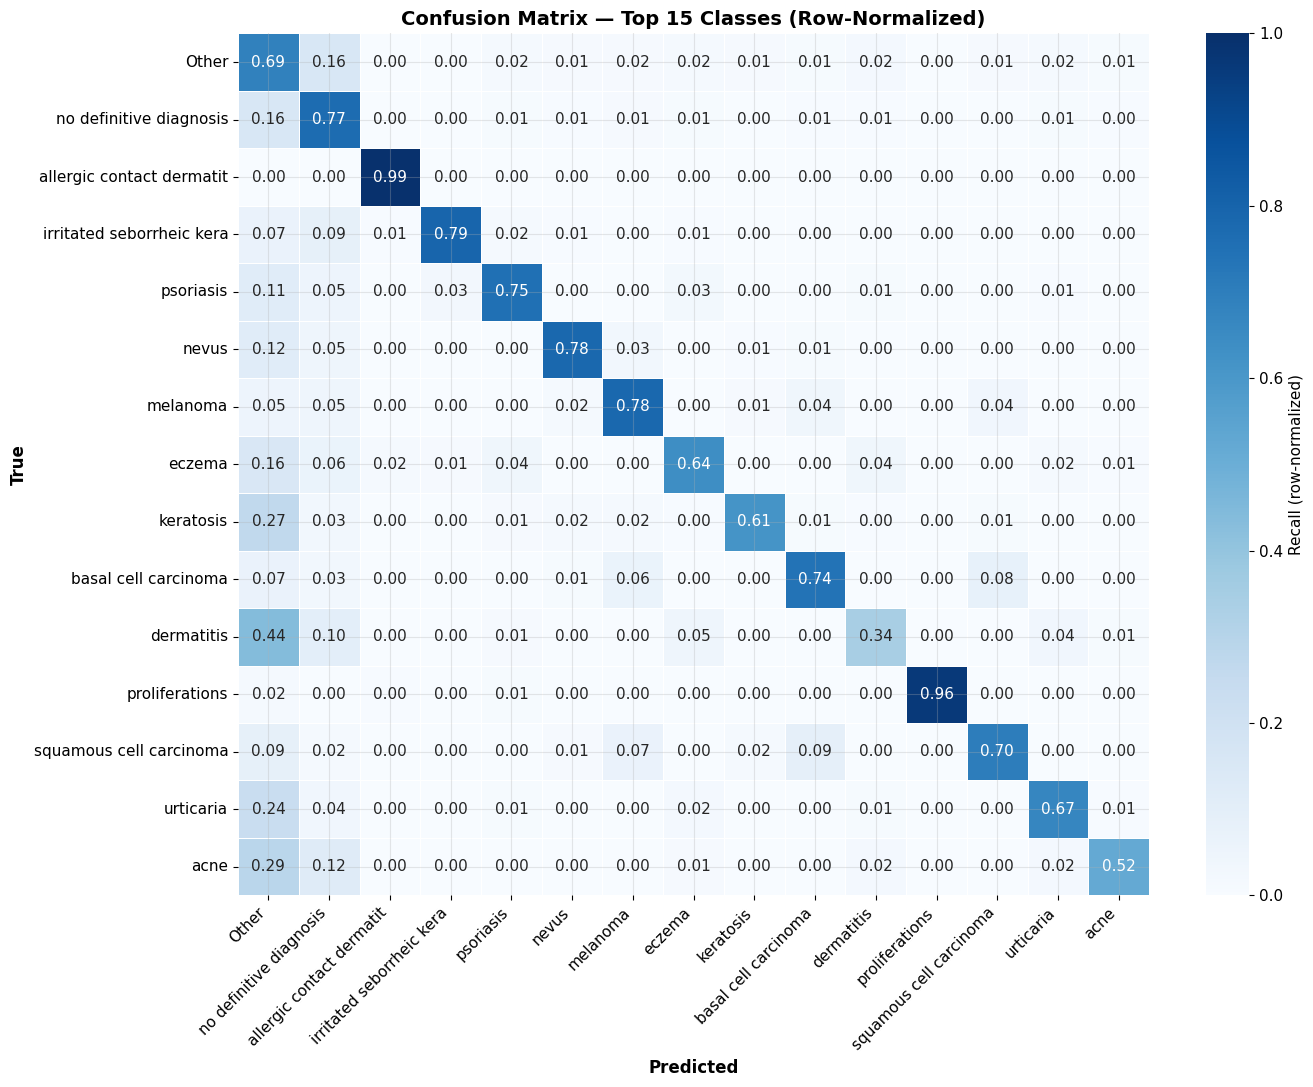

In [25]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Get class counts for sorting
class_counts = full_ds.df['grouped_class'].value_counts().sort_values(ascending=False)
top15 = class_counts.head(15).index.tolist()

# Filter preds/labels to top-15
mask_top = [(l in top15 and p in top15) for l, p in zip(labels, preds)]
labels_t = [l for l, m in zip(labels, mask_top) if m]
preds_t  = [p for p, m in zip(preds,  mask_top) if m]

cm = confusion_matrix(labels_t, preds_t, labels=top15)
# Normalize by row (true class)
cm_norm = cm.astype(float) / (cm.sum(axis=1, keepdims=True) + 1e-6)

top15_names = [full_ds.class_names[c][:25] for c in top15]

fig, ax = plt.subplots(figsize=(14, 11))
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=top15_names, yticklabels=top15_names,
            ax=ax, vmin=0, vmax=1, linewidths=0.5, linecolor='white',
            cbar_kws={'label': 'Recall (row-normalized)'})
ax.set_xlabel('Predicted', fontsize=12, fontweight='bold')
ax.set_ylabel('True', fontsize=12, fontweight='bold')
ax.set_title('Confusion Matrix — Top 15 Classes (Row-Normalized)', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(str(CHECKPOINT_DIR / 'confusion_matrix.png'), dpi=150, bbox_inches='tight')
plt.show()

## Per-Class F1 Score

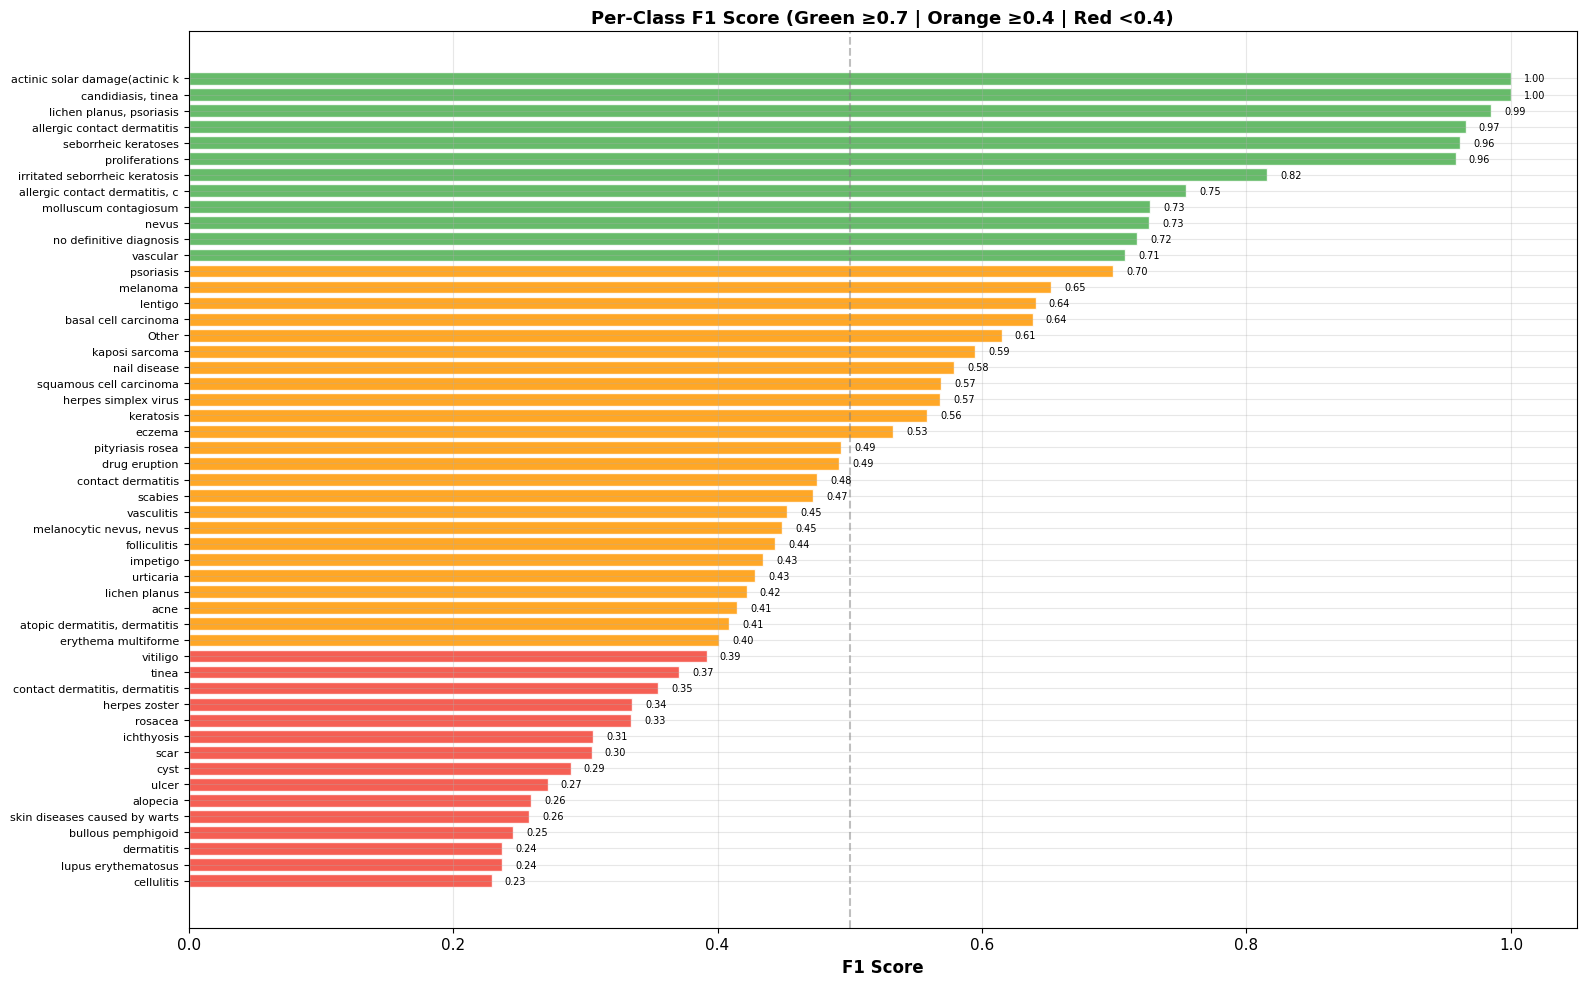

Macro F1:    0.5329
Weighted F1: 0.6750
Classes with F1 ≥ 0.7: 12/51
Classes with F1 < 0.3: 8/51


In [26]:
from sklearn.metrics import f1_score, precision_recall_fscore_support

present_classes = sorted(set(labels) | set(preds))
prec, rec, f1, sup = precision_recall_fscore_support(
    labels, preds, labels=present_classes, zero_division=0
)

# Sort by F1 descending
class_data = []
for i, c in enumerate(present_classes):
    name = full_ds.class_names[c] if c < len(full_ds.class_names) else str(c)
    class_data.append({'name': name[:30], 'f1': f1[i], 'prec': prec[i], 'rec': rec[i], 'support': sup[i]})

class_data.sort(key=lambda x: x['f1'], reverse=True)

fig, ax = plt.subplots(figsize=(16, 10))
names = [d['name'] for d in class_data]
f1s   = [d['f1'] for d in class_data]
colors = ['#4CAF50' if f >= 0.7 else '#FF9800' if f >= 0.4 else '#F44336' for f in f1s]

bars = ax.barh(range(len(names)), f1s, color=colors, edgecolor='white', alpha=0.85)
ax.set_yticks(range(len(names)))
ax.set_yticklabels(names, fontsize=8)
ax.set_xlabel('F1 Score', fontsize=12, fontweight='bold')
ax.set_title('Per-Class F1 Score (Green ≥0.7 | Orange ≥0.4 | Red <0.4)', fontsize=13, fontweight='bold')
ax.axvline(0.5, ls='--', color='gray', alpha=0.5)
ax.invert_yaxis()
ax.set_xlim(0, 1.05)

# Add value labels
for bar, f in zip(bars, f1s):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
            f'{f:.2f}', va='center', fontsize=7)

plt.tight_layout()
plt.savefig(str(CHECKPOINT_DIR / 'per_class_f1.png'), dpi=150, bbox_inches='tight')
plt.show()

# Summary stats
macro_f1 = np.mean(f1s)
weighted_f1 = f1_score(labels, preds, labels=present_classes, average='weighted', zero_division=0)
print(f'Macro F1:    {macro_f1:.4f}')
print(f'Weighted F1: {weighted_f1:.4f}')
print(f'Classes with F1 ≥ 0.7: {sum(1 for f in f1s if f >= 0.7)}/{len(f1s)}')
print(f'Classes with F1 < 0.3: {sum(1 for f in f1s if f < 0.3)}/{len(f1s)}')

## Gate Weight Analysis (Image vs Text Reliance)

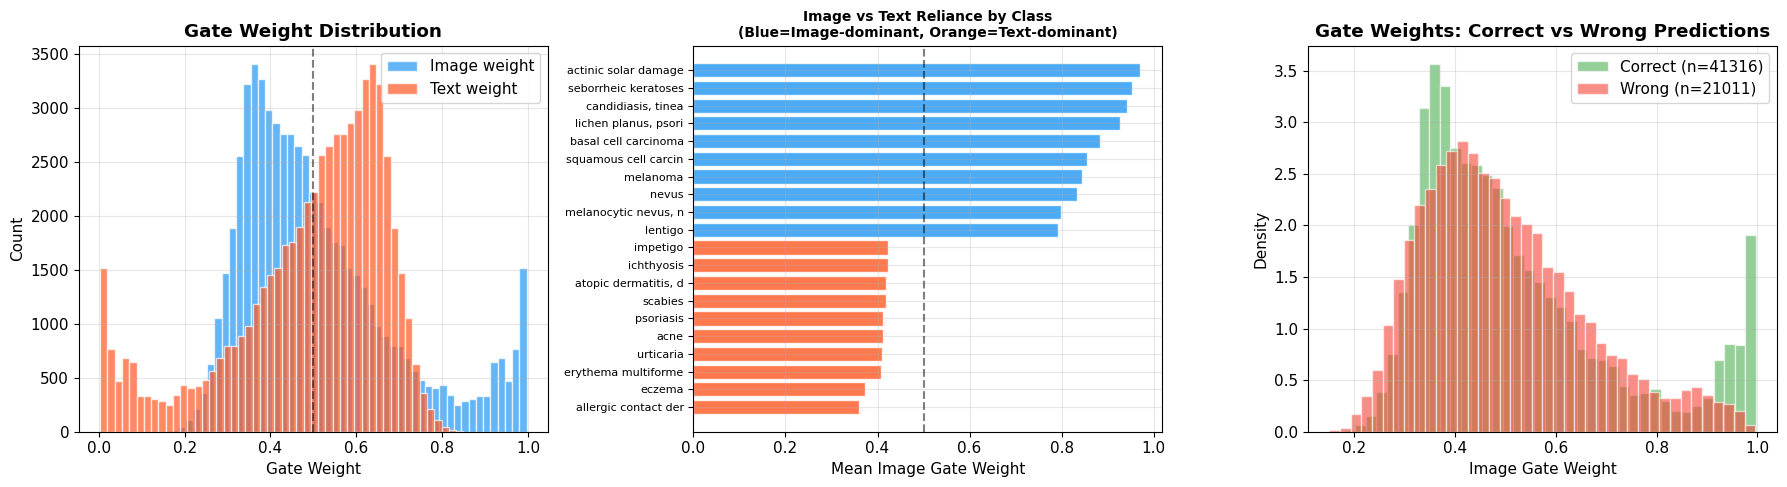

Mean image weight: 0.511 ± 0.184
Mean text weight:  0.489 ± 0.184


In [27]:
gates_arr = np.array(gates)  # (N, 2) — [image_weight, text_weight]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ── Panel 1: Overall distribution ──
ax = axes[0]
ax.hist(gates_arr[:, 0], bins=50, alpha=0.7, color='#2196F3', label='Image weight', edgecolor='white')
ax.hist(gates_arr[:, 1], bins=50, alpha=0.7, color='#FF5722', label='Text weight', edgecolor='white')
ax.axvline(0.5, ls='--', color='black', alpha=0.5)
ax.set_xlabel('Gate Weight'); ax.set_ylabel('Count')
ax.set_title('Gate Weight Distribution', fontweight='bold')
ax.legend()

# ── Panel 2: Per-class mean gate weight ──
ax = axes[1]
class_img_w = {}
for l, g in zip(labels, gates_arr):
    name = full_ds.class_names[l][:20] if l < len(full_ds.class_names) else str(l)
    if name not in class_img_w:
        class_img_w[name] = []
    class_img_w[name].append(g[0])

# Sort by mean image weight
sorted_classes = sorted(class_img_w.items(), key=lambda x: np.mean(x[1]), reverse=True)
top20 = sorted_classes[:10] + sorted_classes[-10:]
cnames = [c[0] for c in top20]
cmeans = [np.mean(c[1]) for c in top20]
colors2 = ['#2196F3' if m > 0.5 else '#FF5722' for m in cmeans]

ax.barh(range(len(cnames)), cmeans, color=colors2, edgecolor='white', alpha=0.8)
ax.set_yticks(range(len(cnames)))
ax.set_yticklabels(cnames, fontsize=8)
ax.axvline(0.5, ls='--', color='black', alpha=0.5)
ax.set_xlabel('Mean Image Gate Weight')
ax.set_title('Image vs Text Reliance by Class\n(Blue=Image-dominant, Orange=Text-dominant)', fontweight='bold', fontsize=10)
ax.invert_yaxis()

# ── Panel 3: Correct vs Incorrect gate weights ──
ax = axes[2]
correct_mask = [l == p for l, p in zip(labels, preds)]
correct_gates = gates_arr[correct_mask]
wrong_gates   = gates_arr[[not c for c in correct_mask]]

ax.hist(correct_gates[:, 0], bins=40, alpha=0.6, color='#4CAF50', label=f'Correct (n={len(correct_gates)})', density=True, edgecolor='white')
ax.hist(wrong_gates[:, 0],   bins=40, alpha=0.6, color='#F44336', label=f'Wrong (n={len(wrong_gates)})',     density=True, edgecolor='white')
ax.set_xlabel('Image Gate Weight'); ax.set_ylabel('Density')
ax.set_title('Gate Weights: Correct vs Wrong Predictions', fontweight='bold')
ax.legend()

plt.tight_layout()
plt.savefig(str(CHECKPOINT_DIR / 'gate_analysis.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f'Mean image weight: {gates_arr[:, 0].mean():.3f} ± {gates_arr[:, 0].std():.3f}')
print(f'Mean text weight:  {gates_arr[:, 1].mean():.3f} ± {gates_arr[:, 1].std():.3f}')

## Summary

In [28]:
from sklearn.metrics import top_k_accuracy_score, f1_score

print('═' * 55)
print('          IT FUSION MODEL — FINAL METRICS')
print('═' * 55)
print(f'  Model:            FusionClassifier (MARIA cross-attn)')
print(f'  Parameters:       {n_params:,}')
print(f'  Classes:          {n_classes} (top-{TOP_K_CLASSES} + Other)')
print(f'  Epochs trained:   {len(history["train_loss"])}')
print(f'─' * 55)
print(f'  Best Val Acc:     {best_val_acc:.4f} ({best_val_acc*100:.1f}%)')
print(f'  Test Accuracy:    {ts_acc:.4f} ({ts_acc*100:.1f}%)')

present_classes_s = sorted(set(labels) | set(preds))
wf1 = f1_score(labels, preds, labels=present_classes_s, average='weighted', zero_division=0)
mf1 = f1_score(labels, preds, labels=present_classes_s, average='macro', zero_division=0)
print(f'  Weighted F1:      {wf1:.4f}')
print(f'  Macro F1:         {mf1:.4f}')
print(f'─' * 55)
print(f'  Train-Val Gap:    {(history["train_acc"][-1] - history["val_acc"][-1])*100:.1f}%')
print(f'  Overfit Status:   {"✅ No" if (history["train_acc"][-1] - history["val_acc"][-1]) < 0.05 else "⚠️ Mild" if (history["train_acc"][-1] - history["val_acc"][-1]) < 0.10 else "❌ Yes"}')
print(f'  Mean Gate (Img):  {gates_arr[:, 0].mean():.3f}')
print(f'  Mean Gate (Txt):  {gates_arr[:, 1].mean():.3f}')
print('═' * 55)

═══════════════════════════════════════════════════════
          IT FUSION MODEL — FINAL METRICS
═══════════════════════════════════════════════════════
  Model:            FusionClassifier (MARIA cross-attn)
  Parameters:       2,558,261
  Classes:          51 (top-50 + Other)
  Epochs trained:   30
───────────────────────────────────────────────────────
  Best Val Acc:     0.6678 (66.8%)
  Test Accuracy:    0.6629 (66.3%)
  Weighted F1:      0.6750
  Macro F1:         0.5329
───────────────────────────────────────────────────────
  Train-Val Gap:    2.2%
  Overfit Status:   ✅ No
  Mean Gate (Img):  0.511
  Mean Gate (Txt):  0.489
═══════════════════════════════════════════════════════


In [29]:
# Save full checkpoint with metadata
label2name = {i: name for i, name in enumerate(full_ds.class_names)}
full_ckpt = {
    'model_state': model.state_dict(),
    'n_classes': n_classes,
    'label2name': label2name,
    'class_names': full_ds.class_names,
    'class_remap': full_ds.class_remap,
    'best_val_acc': best_val_acc,
    'test_acc': ts_acc,
    'config': {
        'IMAGE_DIM': IMAGE_DIM, 'TEXT_DIM': TEXT_DIM,
        'D_MODEL': D_MODEL, 'N_HEADS': N_HEADS,
        'N_LAYERS': N_LAYERS, 'EPOCHS': EPOCHS,
        'BATCH_SIZE': BATCH_SIZE, 'LR': LR,
        'DROPOUT': DROPOUT, 'TOP_K_CLASSES': TOP_K_CLASSES,
    }
}
torch.save(full_ckpt, str(CHECKPOINT_DIR / 'maria_fusion_full_checkpoint.pt'))
print('Full checkpoint saved.')
print(f'Final Test Accuracy: {ts_acc:.4f}')

Full checkpoint saved.
Final Test Accuracy: 0.6629


## Demo: Sample Predictions
Shows 10 random test samples with model predictions, confidence, and image/text gate weights.

In [30]:
# ── Pick 10 random test samples and show predictions ──
model.eval()
demo_indices = np.random.choice(len(test_ds), size=10, replace=False)

print(f'{"#":>3} {"True Label":40s} {"Predicted":40s} {"Conf":>6s} {"Img_W":>6s} {"Txt_W":>6s} {"✓/✗":>4s}')
print('─' * 145)

n_correct = 0
for i, didx in enumerate(demo_indices):
    img_f, txt_f, img_m, txt_m, label = test_ds[didx]
    img_f = img_f.unsqueeze(0).to(DEVICE)
    txt_f = txt_f.unsqueeze(0).to(DEVICE)
    img_m = img_m.unsqueeze(0).to(DEVICE)
    txt_m = txt_m.unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        logits, _, gate_w = model(img_f, txt_f, img_m, txt_m)
        probs = F.softmax(logits, dim=-1)
        pred_idx = probs.argmax(1).item()
        confidence = probs[0, pred_idx].item()
        img_w = gate_w[0, 0].item()
        txt_w = gate_w[0, 1].item()

    true_name = full_ds.class_names[label.item()][:40]
    pred_name = full_ds.class_names[pred_idx][:40]
    match = '✓' if label.item() == pred_idx else '✗'
    if label.item() == pred_idx:
        n_correct += 1

    print(f'{i+1:3d} {true_name:40s} {pred_name:40s} {confidence:6.3f} {img_w:6.3f} {txt_w:6.3f} {match:>4s}')

print('─' * 145)
print(f'Demo accuracy: {n_correct}/10 ({n_correct*10}%)')
print(f'\nGate weights show how much the model relies on Image vs Text for each sample.')

  # True Label                               Predicted                                  Conf  Img_W  Txt_W  ✓/✗
─────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
  1 lentigo                                  lentigo                                   0.511  0.570  0.430    ✓
  2 no definitive diagnosis                  no definitive diagnosis                   0.185  0.541  0.459    ✓
  3 Other                                    Other                                     0.293  0.467  0.533    ✓
  4 allergic contact dermatitis              allergic contact dermatitis               0.713  0.335  0.665    ✓
  5 eczema                                   eczema                                    0.917  0.516  0.484    ✓
  6 no definitive diagnosis                  no definitive diagnosis                   0.597  0.539  0.461    ✓
  7 nevus                                    nevus                    